In [101]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import linalg
from scipy.spatial.distance import cdist
import os
from PIL import Image
import math

A.2: Recover Homographies

In [124]:
def _normalize_points(pts):
    pts = np.asarray(pts, dtype=np.float64)
    mean = pts.mean(axis=0)
    centered = pts - mean
    mean_dist = np.mean(np.sqrt(np.sum(centered**2, axis=1)))
    scale = np.sqrt(2.0) / (mean_dist + 1e-12)
    T = np.array([[scale, 0, -scale*mean[0]],
                  [0, scale, -scale*mean[1]],
                  [0, 0, 1]], dtype=np.float64)
    pts_h = np.hstack([pts, np.ones((pts.shape[0],1))])
    pts_norm = (T @ pts_h.T).T[:, :2]
    return pts_norm, T


def computeH_solve_normalized(im1_pts, im2_pts):
    """
    Normalized DLT but fix h33=1 and solve for the other 8 unknowns via least-squares.
    Returns H mapping im1_pts -> im2_pts (i.e. p2 ~ H p1).
    """
    pts1 = np.asarray(im1_pts, dtype=np.float64)
    pts2 = np.asarray(im2_pts, dtype=np.float64)
    if pts1.shape != pts2.shape or pts1.shape[0] < 4:
        raise ValueError("Need at least 4 correspondences with matching shapes")

    p1n, T1 = _normalize_points(pts1)
    p2n, T2 = _normalize_points(pts2)

    n = p1n.shape[0]
    # Build M u = b where u = [h11 h12 h13 h21 h22 h23 h31 h32]^T and h33 = 1
    M = np.zeros((2*n, 8), dtype=np.float64)
    b = np.zeros((2*n,), dtype=np.float64)
    for i in range(n):
        x, y = p1n[i]
        xp, yp = p2n[i]
        M[2*i]   = [x, y, 1, 0, 0, 0, -xp*x, -xp*y]
        b[2*i]   = xp
        M[2*i+1] = [0, 0, 0, x, y, 1, -yp*x, -yp*y]
        b[2*i+1] = yp

    # If exactly 8 eqns (n=4) solve square system, else least-squares
    if M.shape[0] == 8:
        try:
            u = np.linalg.solve(M, b)   # exact solve (may raise if singular)
        except np.linalg.LinAlgError:
            u, *_ = np.linalg.lstsq(M, b, rcond=None)
    else:
        u, *_ = np.linalg.lstsq(M, b, rcond=None)

    h = np.concatenate([u, [1.0]])   # append h33 = 1
    Hn = h.reshape(3,3)
    # Denormalize
    H = np.linalg.inv(T2) @ Hn @ T1
    if abs(H[2,2]) > 1e-12:
        H = H / H[2,2]
    return H

A.3: Warp the Images

In [125]:
#helper funcitons 
def get_output_size(im, H): 
    h, w = im.shape[:2]

    corner = np.array([[0,0, 1], [w-1, 0, 1], [w-1, h-1, 1], [0, h-1, 1]], dtype=np.float32)

    transformed_corners = (H @ corner.T).T #result 3 x 4 transpose to 4 x 3
    #first two cols divide by the third to create homogenous coord 
    #use [2:3] instead of [2] since we want a column vector not a flat array
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3] 

    min_x = np.floor(np.min(transformed_corners[:, 0])).astype(int)
    max_x = np.ceil(np.max(transformed_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(transformed_corners[:, 1])).astype(int)
    max_y = np.ceil(np.max(transformed_corners[:, 1])).astype(int)

    output_width = max_x - min_x + 1 #inclusive 
    output_height = max_y - min_y + 1 

    return output_width, output_height, (min_x, min_y)

def nearest_neighbor_interp(im, x, y): 
    h, w = im.shape[:2]

    x_round = np.round(x).astype(int)
    y_round = np.round(y).astype(int)

    x_round = np.clip(x_round, 0, w-1)
    y_round = np.clip(y_round, 0, h-1)

    return im[y_round, x_round]

def bilinear_interp(im, x, y): 
    h, w = im.shape[:2]

    x0 = np.floor(x).astype(int)
    x1 = x0 + 1 
    y0 = np.floor(y).astype(int)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, w-1)
    x1 = np.clip(x1, 0, w-1)
    y0 = np.clip(y0, 0, h-1)
    y1 = np.clip(y1, 0, h-1)

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    if len(im.shape) == 3:  #add None to prevent shape mismatch
        interpolated = (wa[:, :, None] * im[y0, x0] +
                       wb[:, :, None] * im[y1, x0] +
                       wc[:, :, None] * im[y0, x1] +
                       wd[:, :, None] * im[y1, x1])
    else: 
        interpolated = (wa * im[y0, x0] +
                       wb * im[y1, x0] +
                       wc * im[y0, x1] +
                       wd * im[y1, x1])
        
    return interpolated.astype(im.dtype)

In [126]:
def warpImage(im, H, interp_func): 
    output_w, output_h, min_pair = get_output_size(im, H)

    if len(im.shape) == 3:
        output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    else:
        output = np.zeros((output_h, output_w, 2), dtype=im.dtype)

    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    x_out_shifted = x_out + min_pair[0]
    y_out_shifted = y_out + min_pair[1]

    #coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)
    coords_out = np.stack([x_out_shifted, y_out_shifted, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (coords_out @ H_inv.T)
    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    print("Projected corners:\n", coords_src)


    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    if len(im.shape) == 3: 
        for c in range(3): 
            output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
            output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
    else: 
        output[:, :, 0] = interp_func(im[:,:,0], x_src, y_src)
        output[:, :, 1] = (mask * 255).astype(im.dtype) 
        
    return output 

In [127]:
#Part 3 functions
def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [128]:
def display(im_original, im_warped, interp_func, title="Image Warping Result"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Display original image
    ax1.imshow(im_original)
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')
    
    # Display warped image
    if len(im_warped.shape) == 3 and im_warped.shape[2] >= 3:
        # Color image with alpha channel
        ax2.imshow(im_warped[:, :, :3])
    else:
        # Grayscale image
        ax2.imshow(im_warped[:, :, 0], cmap='gray')
    
    ax2.set_title(f'Warped Image ({interp_func})', fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

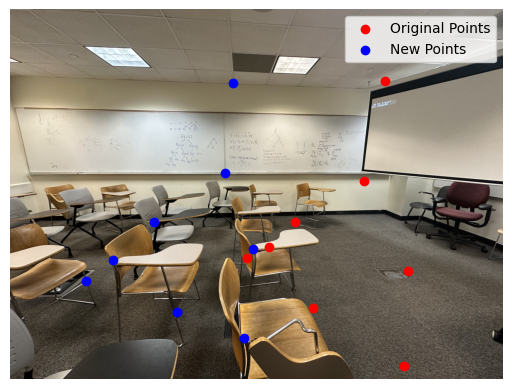

In [132]:
import json

img = plt.imread('../data/IMG_8844.jpg') 
with open('../data/chairs.json', 'r') as f:
    warped_points = json.load(f)

original_pts = np.array(warped_points["im1Points"])
new_pts = np.array(warped_points["im2Points"])


H = computeH_solve_normalized(original_pts,new_pts)
#imwarped_nn = warpImageNearestNeighbor(img,H)
#imwarped_bil = warpImageBilinear(img,H)

# Plot the image
fig, ax = plt.subplots()

# Plot the image
ax.imshow(img)

# Plot the points on the image
ax.scatter(original_pts[:, 0], original_pts[:, 1], c='r', label='Original Points')
ax.scatter(new_pts[:, 0], new_pts[:, 1], c='b', label='New Points')

ax.legend()
ax.axis('off')
plt.show()

In [133]:
print(f"Homography matrix:\n{H}")
output_w, output_h, min_pair = get_output_size(img, H)
print(f"Output size: {output_w} x {output_h}")
print(f"This is {output_w * output_h:,} pixels!")

#mwarped_nn = warpImageNearestNeighbor(img, H)
imwarped_bil = warpImageBilinear(img,H)


#display(img, imwarped_nn, "Nearest Neighbor")

display(img, imwarped_bil, "Bilinear")


Homography matrix:
[[ 1.70452552e+01 -4.77051233e-01 -2.68075620e+04]
 [ 5.52124769e+00  1.18376943e+01 -1.56585205e+04]
 [ 4.14817886e-03 -2.17777080e-04  1.00000000e+00]]
Output size: 85057 x 74569
This is 6,342,615,433 pixels!


MemoryError: Unable to allocate 94.5 GiB for an array with shape (2, 74569, 85057) and data type int64

A.4: Blend the Images into a Mosaic

In [ ]:
from scipy import ndimage

def create_distance_weights(mask):
    if not np.any(mask):
        return np.zeros_like(mask, dtype=np.float32)
    
    dist_transform = ndimage.distance_transform_edt(mask)
    
    if np.max(dist_transform) > 0:
        weights = dist_transform / np.max(dist_transform)
    else:
        weights = mask.astype(np.float32)
    
    return weights

In [129]:
def compose_mosaic_proper_blending(img1, img2, H2, interp_func):
 
    h2, w2 = img2.shape[:2]
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    transformed_corners2 = corners2 @ H2.T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]

    h1, w1 = img1.shape[:2]
    corners1 = np.array([[0, 0], [w1-1, 0], [w1-1, h1-1], [0, h1-1]], dtype=np.float32)

    all_corners = np.vstack([corners1, transformed_corners2])
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1

    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])

    H2_adjusted = T @ H2

    warped_img2 = warpImage(img2, H2_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    offset_x, offset_y = -min_x, -min_y
    
    canvas = np.zeros((mosaic_height, mosaic_width, 4), dtype=np.uint8)
    weight_map = np.zeros((mosaic_height, mosaic_width), dtype=np.float32)
    color_sum = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.float32)
    
    # Place img1
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    
    # Simple weights for img1 (all 1.0 for now)
    img1_weights = np.ones((h1, w1), dtype=np.float32)
    
    for c in range(3):
        color_sum[y1_start:y1_end, x1_start:x1_end, c] += (
            img1[:, :, c].astype(np.float32) * img1_weights
        )
    weight_map[y1_start:y1_end, x1_start:x1_end] += img1_weights
    canvas[y1_start:y1_end, x1_start:x1_end, 3] = 255
    
    h_warped, w_warped = warped_img2.shape[:2]
    warped_region = warped_img2[:h_warped, :w_warped]
    warped_mask = warped_region[:, :, 3] > 0
    
    if np.any(warped_mask):
        warped_weights = warped_mask.astype(np.float32)
        
        for c in range(3):
            color_sum[:h_warped, :w_warped, c] += (
                warped_region[:, :, c].astype(np.float32) * warped_weights
            )
        weight_map[:h_warped, :w_warped] += warped_weights
        canvas[:h_warped, :w_warped, 3] = np.maximum(
            canvas[:h_warped, :w_warped, 3], 
            warped_region[:, :, 3]
        )
    
    valid_weights = weight_map > 0
    for c in range(3):
        canvas[:, :, c][valid_weights] = np.clip(
            color_sum[:, :, c][valid_weights] / weight_map[valid_weights], 
            0, 255
        ).astype(np.uint8)

    # Auto-crop 
    alpha_channel = canvas[:, :, 3]
    rows = np.any(alpha_channel > 0, axis=1)
    cols = np.any(alpha_channel > 0, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        cropped_canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped from {mosaic_width}x{mosaic_height} to {cropped_canvas.shape[1]}x{cropped_canvas.shape[0]}")
    else:
        cropped_canvas = canvas
        print("No cropping applied")

    return cropped_canvas

In [130]:
def warpImage(im, H, interp_func): 
    output_w, output_h, min_pair = get_output_size(im, H)

    if len(im.shape) == 3:
        output = np.zeros((output_h, output_w, 4), dtype=im.dtype)  # RGBA
    else:
        output = np.zeros((output_h, output_w, 2), dtype=im.dtype)

    #assign point coord values 
    y_out, x_out = np.mgrid[0:output_h, 0:output_w]
    

    coords_out = np.stack([x_out, y_out, np.ones_like(x_out)], axis=-1)

    H_inv = np.linalg.inv(H)
    coords_src = (coords_out @ H_inv.T)
    coords_src = coords_src[:, :, :2]/coords_src[:,:,2:3]

    x_src = coords_src[:, :, 0]
    y_src = coords_src[:, :, 1]

    h_src, w_src = im.shape[:2]
    mask = (x_src >= 0) & (x_src <= w_src-1) & (y_src >= 0) & (y_src <= h_src-1)

    if len(im.shape) == 3: 
        for c in range(3): 
            output[:,:,c] = interp_func(im[:,:,c], x_src, y_src)
            output[:,:,c] = output[:,:,c] * mask
        output[:, :, 3] = (mask * 255).astype(im.dtype)  #transparent = 0 
    else: 
        output[:, :, 0] = interp_func(im[:,:,0], x_src, y_src)
        output[:, :, 1] = (mask * 255).astype(im.dtype) 
        
    return output 

def warpImageNearestNeighbor(im, H): 
    return warpImage(im, H, nearest_neighbor_interp)
def warpImageBilinear(im, H):
    return warpImage(im, H, bilinear_interp)

In [131]:
def get_H(json_path): 
    with open(json_path, 'r') as f:
        warped_points = json.load(f)

    original_pts = np.array(warped_points["im1Points"])
    new_pts = np.array(warped_points["im2Points"])


    H = computeH(original_pts,new_pts)
    return H, original_pts, new_pts

In [132]:
# Get your homography and points
H, original_pts, new_pts = get_H('../data/VA.json')

img1 = plt.imread('../data/IMG_8849.jpg') 
img2 = plt.imread('../data/IMG_8848.jpg') 

# Call the function with points
mosaic = compose_mosaic_proper_blending(img1, img2, H, nearest_neighbor_interp)


Mosaic size: 9333 x 5548
Warped image size: (5548, 7017, 4)
Cropped from 9333x5548 to 7027x4703


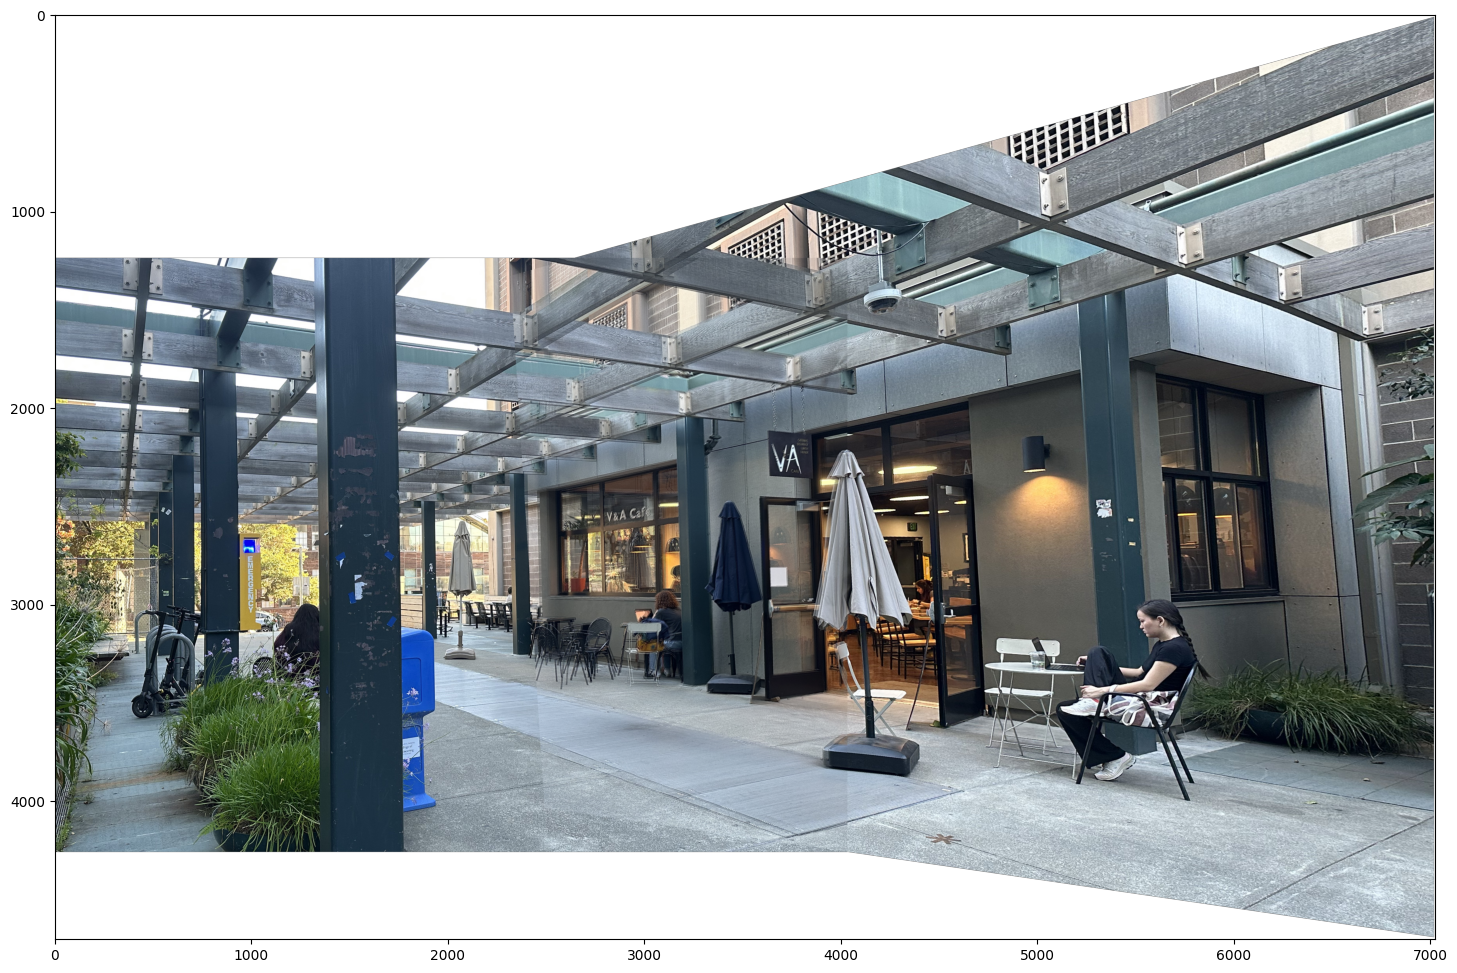

In [133]:

fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()

In [160]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def create_blending_mask(warped_img, reference_img):
    """
    Create smooth blending mask using distance transform
    """
    # Create masks from non-zero pixels
    mask_warped = np.any(warped_img > 0, axis=2).astype(np.uint8)
    mask_reference = np.any(reference_img > 0, axis=2).astype(np.uint8)
    
    # Compute distance transforms
    dist_warped = ndimage.distance_transform_edt(mask_warped)
    dist_reference = ndimage.distance_transform_edt(mask_reference)
    
    # Create smooth alpha mask
    # Where both images overlap, use distance-based weights
    # Where only one image exists, use that image completely
    alpha_mask = np.zeros_like(dist_warped, dtype=np.float32)
    
    # Areas where both images have content
    overlap_mask = (mask_warped > 0) & (mask_reference > 0)
    if np.any(overlap_mask):
        total_dist = dist_warped[overlap_mask] + dist_reference[overlap_mask]
        alpha_mask[overlap_mask] = dist_warped[overlap_mask] / total_dist
    
    # Areas where only warped image has content
    warped_only = (mask_warped > 0) & (mask_reference == 0)
    alpha_mask[warped_only] = 1.0
    
    # Areas where only reference has content remain 0
    
    return alpha_mask

def blend_images_weighted(img1, img2, alpha_mask):
    """
    Blend images using weighted average with smooth alpha mask
    """
    # Ensure alpha mask has 3 channels for RGB
    if len(alpha_mask.shape) == 2:
        alpha_mask = alpha_mask[:, :, np.newaxis]
    
    # Convert to float for blending
    img1_float = img1.astype(np.float32)
    img2_float = img2.astype(np.float32)
    
    # Weighted blending
    blended = img1_float * alpha_mask + img2_float * (1.0 - alpha_mask)
    
    return np.clip(blended, 0, 255).astype(np.uint8)

def compose_mosaic_distance_blend(img1, img2, H, interp_func):
    """
    Compose mosaic using distance-transform based blending 
    """
    
    # Step 1: Calculate mosaic bounding box
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Transform corners of both images
    corners1 = np.array([[0, 0, 1], [w1-1, 0, 1], [w1-1, h1-1, 1], [0, h1-1, 1]], dtype=np.float32)
    corners2 = np.array([[0, 0, 1], [w2-1, 0, 1], [w2-1, h2-1, 1], [0, h2-1, 1]], dtype=np.float32)
    
    transformed_corners2 = (H @ corners2.T).T
    transformed_corners2 = transformed_corners2[:, :2] / transformed_corners2[:, 2:3]
    
    all_corners = np.vstack([corners1[:, :2], transformed_corners2])
    
    min_x, min_y = np.floor(np.min(all_corners, axis=0)).astype(int)
    max_x, max_y = np.ceil(np.max(all_corners, axis=0)).astype(int)
    
    mosaic_width = max_x - min_x + 1
    mosaic_height = max_y - min_y + 1
    
    print(f"Mosaic size: {mosaic_width} x {mosaic_height}")

    # Step 2: Adjust homography for mosaic coordinates
    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])
    H_adjusted = T @ H

    # Step 3: Warp img2
    warped_img2 = warpImage(img2, H_adjusted, interp_func)
    print(f"Warped image size: {warped_img2.shape}")

    # Step 4: Create canvas and place images
    canvas = np.zeros((mosaic_height, mosaic_width, 3), dtype=np.uint8)
    
    # Place img1 (reference image)
    offset_x, offset_y = -min_x, -min_y
    y1_start, y1_end = offset_y, offset_y + h1
    x1_start, x1_end = offset_x, offset_x + w1
    canvas[y1_start:y1_end, x1_start:x1_end] = img1

    # Step 5: Get regions for blending
    h_warped, w_warped = warped_img2.shape[:2]
    warped_rgb = warped_img2[:, :, :3]  # Extract RGB
    
    # Get the corresponding region from canvas
    canvas_region = canvas[:h_warped, :w_warped]
    
    # Step 6: Create blending mask and blend
    alpha_mask = create_blending_mask(warped_rgb, canvas_region)
    
    # Apply blending
    blended_region = blend_images_weighted(warped_rgb, canvas_region, alpha_mask)
    
    # Update canvas with blended result
    canvas[:h_warped, :w_warped] = blended_region

    # Step 7: Auto-crop to remove empty borders
    non_empty_mask = np.any(canvas > 0, axis=2)
    rows = np.any(non_empty_mask, axis=1)
    cols = np.any(non_empty_mask, axis=0)
    
    if np.any(rows) and np.any(cols):
        ymin, ymax = np.where(rows)[0][[0, -1]]
        xmin, xmax = np.where(cols)[0][[0, -1]]
        
        # Add small padding
        pad = 10
        ymin = max(0, ymin - pad)
        ymax = min(mosaic_height-1, ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(mosaic_width-1, xmax + pad)
        
        canvas = canvas[ymin:ymax+1, xmin:xmax+1]
        print(f"Cropped to: {canvas.shape[1]} x {canvas.shape[0]}")

    return canvas


In [ ]:
# Get your homography and points
H, original_pts, new_pts = get_H('../data/chairs.json')

img1 = plt.imread('../data/IMG_8843.jpg') 
img2 = plt.imread('../data/IMG_8844.jpg') 

# Call the function with points
mosaic = compose_mosaic_distance_blend(img1, img2, H, bilinear_interp)
fig, axes = plt.subplots(figsize=(18, 12))
plt.imshow(mosaic)
plt.show()

Mosaic size: 18236 x 22152
